<a href="https://colab.research.google.com/github/Htar-Su/_HTAR_Deep_RL_Course_by_Hugging_Face/blob/main/RL_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Training a LunarLander-v3 RL Agent Using Proximal Policy Optimization (PPO)**

>The environment: **LunarLander-v3**\
The library used: **Stable-Baselines3**


In [ ]:
# Install dependencies

!apt install swig cmake # This command installs the 'SWIG' and 'CMake' system tools required to build and install some reinforcement learning libraries and environments.
!pip install gymnasium
!pip install "gymnasium[box2d]"   # Contains the LunarLander-v3 environment
!pip install stable-baselines3[extra] # The deep reinforcement learning library.


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 53 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 2s (512 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubunt

In [ ]:
import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# create our environment with gym.make
env = gym.make("LunarLander-v3")
env.reset()
print("_____OBSERVATION SPACE_____ \n")
print("Observation Space Shape:", env.observation_space.shape)
print("Sample observation:", env.observation_space.sample()) # Get a random observation

_____OBSERVATION SPACE_____ 

Observation Space Shape: (8,)
Sample observation: [ 0.25335565  0.8620904   6.7012043  -0.02572873  1.7382299   2.410445
  0.45812     0.54166234]


In [ ]:
print("\n _____ACTION SPACE_____ \n")
print("Action Space Shape:", env.action_space.n)
print("Action Space Sample:", env.action_space.sample()) # Take a random action


 _____ACTION SPACE_____ 

Action Space Shape: 4
Action Space Sample: 1


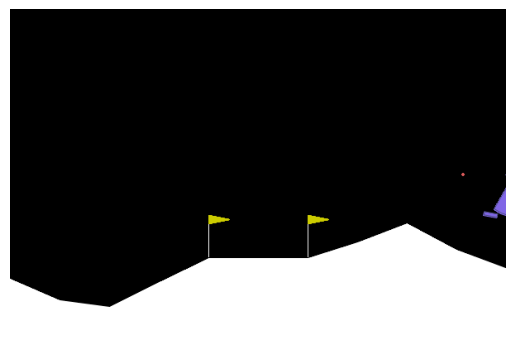

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

env = gym.make("LunarLander-v3", render_mode="rgb_array")
observation, info = env.reset()

fig, ax = plt.subplots()
img_artist = ax.imshow(env.render())
ax.axis("off")
handle = display.display(fig, display_id=True)

for _ in range(100):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)

    img_artist.set_data(env.render())
    handle.update(fig)

    if terminated or truncated:
        observation, info = env.reset()

plt.close(fig)
env.close()

In [ ]:
# Create the vectorized environment
env = make_vec_env('LunarLander-v3', n_envs=16)

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [ ]:
# Create the Model
# Define a PPO MlpPolicy architecture
# Use MultiLayerPerceptron (MLPPolicy) because the input is a vector,
# Add some parameters to accelerate the training
model = PPO(
    policy = 'MlpPolicy',
    env = env,
    n_steps = 1024,
    batch_size = 64,
    n_epochs = 4,
    gamma = 0.999,
    gae_lambda = 0.98,
    ent_coef = 0.01,
    verbose=1,
    tensorboard_log="./ppo_lunarlander_tensorboard/")

Using cuda device


In [ ]:
# Train it for 1,000,000 timesteps
# model.learn(total_timesteps=1000000)
model.learn(total_timesteps=100)

Logging to ./ppo_lunarlander_tensorboard/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 93.1     |
|    ep_rew_mean     | -176     |
| time/              |          |
|    fps             | 3378     |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 16384    |
---------------------------------


In [ ]:
#Learning curve (inline tensor board)

%load_ext tensorboard
%tensorboard --logdir ./ppo_lunarlander_tensorboard/

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<Popen: returncode: None args: ['tensorboard', '--logdir', './ppo_lunarlande...>

In [ ]:
#Learning curve (open tensor board in a separate browser)

import subprocess
subprocess.Popen(["tensorboard", "--logdir", "./ppo_lunarlander_tensorboard/", "--host", "0.0.0.0", "--port", "6006"])

# from google.colab import output
# output.serve_kernel_port_as_window(6006)

# Get just the URL instead of auto-opening
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(6006)")
print(url)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


https://6006-gpu-t4-s-kkb-ass1a0-kcf4bfh792i7-a.asia-southeast1-0.prod.colab.dev


In [ ]:
# Save the model
model_name = "ppo-LunarLander-v3"
model.save(model_name)

In [ ]:
# Evaluate the agent
# Create a new environment for evaluation
eval_env = Monitor(gym.make("LunarLander-v3", render_mode='rgb_array')) #Remember to wrap the environment in a Monitor.

# Load your trained model (skip this if it's already in memory)
model = PPO.load("ppo-LunarLander-v3")

# Evaluate the model with 10 evaluation episodes and deterministic=True
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)

# Print the results
print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

mean_reward=243.39 +/- 48.00540524054661


In [ ]:
# Visualize the agent's performance across episodes.

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from stable_baselines3 import PPO

# Load your trained model
model = PPO.load("ppo-LunarLander-v3")

env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda ep: True)

n_episodes = 5 # Record five episodes, generating one video for each episode.
for ep in range (n_episodes):
    observation, info = env.reset()
    terminated = truncated = False
    while not (terminated or truncated):
        action, _states = model.predict(observation, deterministic=True)
        observation, reward, terminated, truncated, info = env.step(action)

env.close()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos1 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
from IPython.display import Video
Video("./videos1/rl-video-episode-4.mp4", embed=True)